In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle
import matplotlib.patches as mpatches
from sklearn.preprocessing import MinMaxScaler

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 读取数据
df = pd.read_csv('data_merge.csv')

# 显示数据概况
print("数据形状:", df.shape)
print("\n数据类型统计:")
print(df['type'].value_counts())
print("\n数据前5行:")
print(df.head())


数据形状: (9204, 4)

数据类型统计:
type
Hydro                  7156
Biomass                1430
Hydrogen                334
CCUS                    202
Grid interconnector      80
SMR                       2
Name: count, dtype: int64

数据前5行:
    type  latitude  longitude  capacity_mw
0  Hydro   32.3220    65.1190        33.00
1  Hydro   34.5560    69.4787        66.00
2  Hydro   34.6410    69.7170       100.00
3  Hydro   34.4847    70.3633        11.55
4  Hydro   35.9416    68.7100         6.00


In [2]:
# 按类型分别归一化capacity_mw
def normalize_by_type(group):
    scaler = MinMaxScaler(feature_range=(20, 500))  # 设置圆圈大小范围
    group['normalized_capacity'] = scaler.fit_transform(group[['capacity_mw']])
    return group

# 按type分组并归一化
df_normalized = df.groupby('type').apply(normalize_by_type).reset_index(drop=True)

# 检查归一化结果
print("归一化后的统计信息:")
for t in df_normalized['type'].unique():
    subset = df_normalized[df_normalized['type'] == t]
    print(f"\n{t} 类型:")
    print(f"  原始容量范围: {subset['capacity_mw'].min():.2f} - {subset['capacity_mw'].max():.2f} MW")
    print(f"  归一化范围: {subset['normalized_capacity'].min():.2f} - {subset['normalized_capacity'].max():.2f}")
    print(f"  数据点数量: {len(subset)}")


归一化后的统计信息:

Biomass 类型:
  原始容量范围: 1.00 - 528.00 MW
  归一化范围: 20.00 - 500.00
  数据点数量: 1430

CCUS 类型:
  原始容量范围: 0.00 - 0.00 MW
  归一化范围: 20.00 - 20.00
  数据点数量: 202

Grid interconnector 类型:
  原始容量范围: 0.01 - 50.94 MW
  归一化范围: 20.00 - 500.00
  数据点数量: 80

Hydro 类型:
  原始容量范围: 1.00 - 22500.00 MW
  归一化范围: 20.00 - 500.00
  数据点数量: 7156

Hydrogen 类型:
  原始容量范围: 0.00 - 260.00 MW
  归一化范围: 20.00 - 500.00
  数据点数量: 334

SMR 类型:
  原始容量范围: 70.00 - 400.00 MW
  归一化范围: 20.00 - 500.00
  数据点数量: 2


/var/folders/lf/8l0zm0xn3c327_tj0bzr6f4h0000gn/T/ipykernel_92346/4259250665.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_normalized = df.groupby('type').apply(normalize_by_type).reset_index(drop=True)


识别的电站类型: ['Biomass' 'CCUS' 'Grid interconnector' 'Hydro' 'Hydrogen' 'SMR']


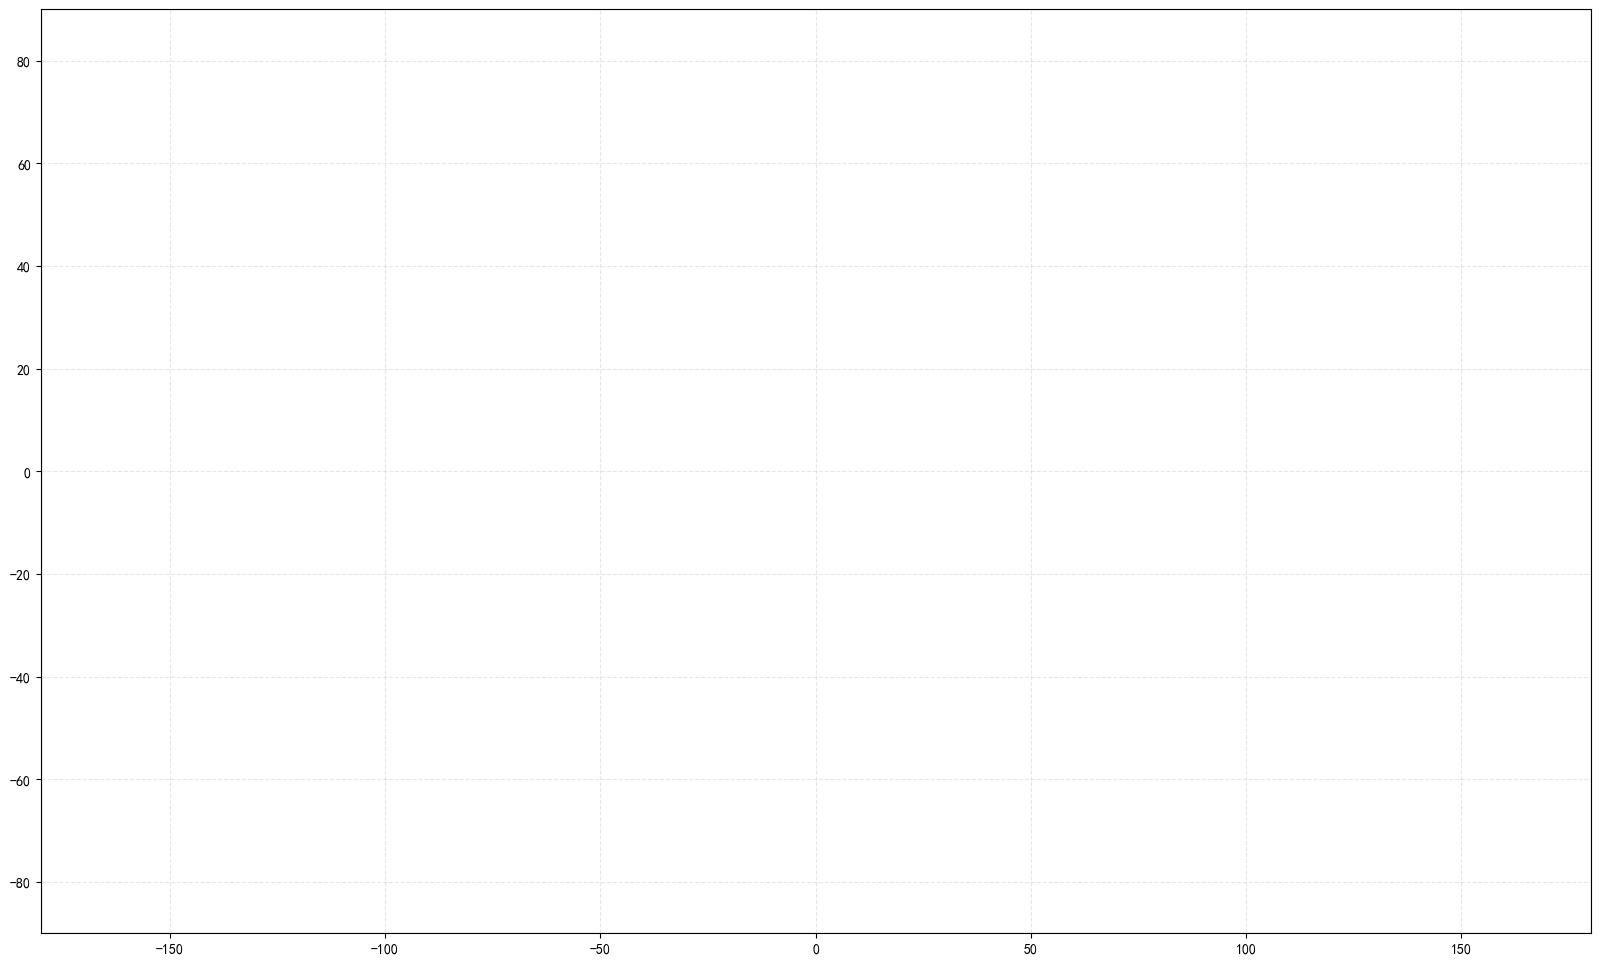

In [7]:
# 创建世界地图可视化
fig, ax = plt.subplots(figsize=(20, 12), dpi=100)

# 设置地图边界（世界地图范围）
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)

# 绘制简单的世界地图轮廓（使用矩形框架表示）
ax.add_patch(plt.Rectangle((-180, -90), 360, 180, fill=False, edgecolor='lightgray', linewidth=1))

# 添加网格线
ax.grid(True, alpha=0.3, linestyle='--')

# 定义不同类型的颜色
type_colors = {
    'Hydro': '#1f77b4',      # 蓝色
    'Biomass': '#ff7f0e',    # 橙色
    'Nuclear': '#2ca02c',    # 绿色
    'Solar': '#d62728',      # 红色
    'Wind': '#9467bd',       # 紫色
    'Geothermal': '#8c564b', # 棕色
    'Coal': '#e377c2',       # 粉色
    'Gas': '#7f7f7f',        # 灰色
    'Oil': '#bcbd22',        # 黄绿色
    'Other': '#17becf'       # 青色
}

# 为每种类型分配颜色
unique_types = df_normalized['type'].unique()
for i, t in enumerate(unique_types):
    if t not in type_colors:
        # 如果类型不在预定义颜色中，使用默认颜色
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_types)))
        type_colors[t] = colors[i]

print("识别的电站类型:", unique_types)


In [5]:
# 创建更详细的统计信息
print("=" * 60)
print("数据统计详情:")
print("=" * 60)

for station_type in unique_types:
    type_data = df_normalized[df_normalized['type'] == station_type]
    print(f"\n{station_type} 类型电站:")
    print(f"  数量: {len(type_data)} 个")
    print(f"  容量范围: {type_data['capacity_mw'].min():.2f} - {type_data['capacity_mw'].max():.2f} MW")
    print(f"  平均容量: {type_data['capacity_mw'].mean():.2f} MW")
    print(f"  总容量: {type_data['capacity_mw'].sum():.2f} MW")
    
    # 地理分布
    print(f"  经度范围: {type_data['longitude'].min():.2f}° - {type_data['longitude'].max():.2f}°")
    print(f"  纬度范围: {type_data['latitude'].min():.2f}° - {type_data['latitude'].max():.2f}°")

print(f"\n总计: {len(df_normalized)} 个电站")
print(f"总容量: {df_normalized['capacity_mw'].sum():.2f} MW")


数据统计详情:

Biomass 类型电站:
  数量: 1430 个
  容量范围: 1.00 - 528.00 MW
  平均容量: 23.97 MW
  总容量: 34281.30 MW
  经度范围: -127.45° - 179.39°
  纬度范围: -38.54° - 65.97°

CCUS 类型电站:
  数量: 202 个
  容量范围: 0.00 - 0.00 MW
  平均容量: 0.00 MW
  总容量: 0.00 MW
  经度范围: -119.30° - 151.92°
  纬度范围: -38.53° - 70.69°

Grid interconnector 类型电站:
  数量: 80 个
  容量范围: 0.01 - 50.94 MW
  平均容量: 4.17 MW
  总容量: 333.54 MW
  经度范围: -99.13° - 106.92°
  纬度范围: -34.58° - 60.17°

Hydro 类型电站:
  数量: 7156 个
  容量范围: 1.00 - 22500.00 MW
  平均容量: 147.17 MW
  总容量: 1053159.62 MW
  经度范围: -159.63° - 178.05°
  纬度范围: -53.79° - 70.37°

Hydrogen 类型电站:
  数量: 334 个
  容量范围: 0.00 - 260.00 MW
  平均容量: 3.94 MW
  总容量: 1316.08 MW
  经度范围: -122.69° - 151.20°
  纬度范围: -52.03° - 70.77°

SMR 类型电站:
  数量: 2 个
  容量范围: 70.00 - 400.00 MW
  平均容量: 235.00 MW
  总容量: 470.00 MW
  经度范围: 122.53° - 160.00°
  纬度范围: 36.97° - 57.00°

总计: 9204 个电站
总容量: 1089560.54 MW
